In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [11]:
path = "/kaggle/input/datasets/sirakri19/htru2-dataset/HTRU_2.csv"
df = pd.read_csv(path, header=None)

In [13]:
df.columns = [
    "ip_mean", "ip_std", "ip_kurtosis", "ip_skew",
    "dm_mean", "dm_std", "dm_kurtosis", "dm_skew",
    "label"
]

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ip_mean      17898 non-null  float64
 1   ip_std       17898 non-null  float64
 2   ip_kurtosis  17898 non-null  float64
 3   ip_skew      17898 non-null  float64
 4   dm_mean      17898 non-null  float64
 5   dm_std       17898 non-null  float64
 6   dm_kurtosis  17898 non-null  float64
 7   dm_skew      17898 non-null  float64
 8   label        17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [15]:
X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train class distribution:
label
0    0.908441
1    0.091559
Name: proportion, dtype: float64

Test class distribution:
label
0    0.90838
1    0.09162
Name: proportion, dtype: float64


In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [21]:
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0     0.9908    0.9752    0.9829      4065
           1     0.7869    0.9098    0.8439       410

    accuracy                         0.9692      4475
   macro avg     0.8888    0.9425    0.9134      4475
weighted avg     0.9721    0.9692    0.9702      4475

ROC AUC: 0.9751267512675126


In [23]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [24]:
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred, digits=4))
print("ROC AUC:", roc_auc_score(y_test, rf_prob))

              precision    recall  f1-score   support

           0     0.9884    0.9867    0.9876      4065
           1     0.8705    0.8854    0.8779       410

    accuracy                         0.9774      4475
   macro avg     0.9295    0.9360    0.9327      4475
weighted avg     0.9776    0.9774    0.9775      4475

ROC AUC: 0.9745954459544595


In [25]:
rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

rf_importance

,feature,importance
2,ip_kurtosis,0.337071
0,ip_mean,0.174753
3,ip_skew,0.164177
5,dm_std,0.116059
4,dm_mean,0.077714
7,dm_skew,0.061520
6,dm_kurtosis,0.039578
1,ip_std,0.029128


In [30]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [31]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, xgb_pred, digits=4))
print("ROC AUC:", roc_auc_score(y_test, xgb_prob))

              precision    recall  f1-score   support

           0     0.9898    0.9771    0.9834      4065
           1     0.7987    0.9000    0.8463       410

    accuracy                         0.9701      4475
   macro avg     0.8942    0.9386    0.9149      4475
weighted avg     0.9723    0.9701    0.9709      4475

ROC AUC: 0.9759253592535926


In [33]:
# Probabilities from each model
prob_lr = y_prob                  # Logistic Regression (already computed)
prob_rf = rf_prob                 # Random Forest
prob_xgb = xgb_prob               # XGBoost

In [35]:
confidence = np.mean(
    np.vstack([prob_lr, prob_rf, prob_xgb]),
    axis=0
)

disagreement = np.std(
    np.vstack([prob_lr, prob_rf, prob_xgb]),
    axis=0
)

In [36]:
def judge_verdict(conf, dis):
    if conf >= 0.75 and dis < 0.10:
        return "Likely Pulsar"
    elif conf <= 0.25 and dis < 0.10:
        return "Noise"
    else:
        return "Borderline"

In [37]:
verdicts = [judge_verdict(c, d) for c, d in zip(confidence, disagreement)]

In [38]:
judge_df = X_test.copy()
judge_df["true_label"] = y_test.values

judge_df["prob_lr"] = prob_lr
judge_df["prob_rf"] = prob_rf
judge_df["prob_xgb"] = prob_xgb

judge_df["confidence"] = confidence
judge_df["disagreement"] = disagreement
judge_df["verdict"] = verdicts

judge_df.head()

,ip_mean,ip_std,ip_kurtosis,ip_skew,dm_mean,dm_std,dm_kurtosis,dm_skew,true_label,prob_lr,prob_rf,prob_xgb,confidence,disagreement,verdict
1261,122.273438,54.319183,0.094512,-0.457877,1.575251,13.894557,12.022667,169.079155,0,0.028996,0.000000,0.007333,0.012110,0.012310,Noise
2554,123.164062,47.090965,0.017651,0.061258,10.924749,41.232346,3.872715,14.113983,0,0.056448,0.000000,0.002552,0.019667,0.026029,Noise
9121,124.492188,45.940178,0.020541,0.509969,2.153010,16.110846,10.696142,133.917948,0,0.014592,0.000000,0.001032,0.005208,0.006649,Noise
8051,7.796875,33.059690,6.139090,38.708198,109.125418,55.704857,0.682692,-0.374733,1,0.999983,0.999808,0.998669,0.999487,0.000583,Likely Pulsar
7877,128.968750,53.591472,-0.119461,-0.328695,6.076087,33.493324,5.683744,31.843758,0,0.026624,0.017475,0.001689,0.015263,0.010299,Noise


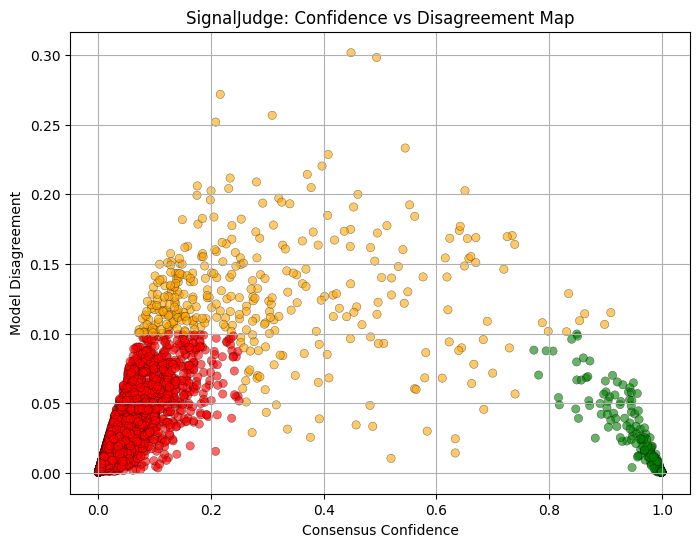

In [40]:
import matplotlib.pyplot as plt

color_map = {
    "Likely Pulsar": "green",
    "Noise": "red",
    "Borderline": "orange"
}

colors = judge_df["verdict"].map(color_map)

plt.figure(figsize=(8, 6))
plt.scatter(
    judge_df["confidence"],
    judge_df["disagreement"],
    c=colors,
    alpha=0.6,
    edgecolors="k",
    linewidths=0.3
)

plt.xlabel("Consensus Confidence")
plt.ylabel("Model Disagreement")
plt.title("SignalJudge: Confidence vs Disagreement Map")

plt.grid(True)
plt.show()

In [42]:
judge_df["is_pulsar"] = judge_df["true_label"] == 1

summary = judge_df.groupby("verdict")["is_pulsar"].agg(
    total="count",
    pulsars="sum"
)

summary["pulsar_ratio"] = summary["pulsars"] / summary["total"]
summary

,total,pulsars,pulsar_ratio
verdict,,,
Borderline,358,39,0.108939
Likely Pulsar,382,348,0.910995
Noise,3735,23,0.006158


In [43]:
pd.crosstab(
    judge_df["verdict"],
    judge_df["true_label"],
    rownames=["Judge Verdict"],
    colnames=["True Label"]
)

True Label,0,1
Judge Verdict,,
Borderline,319,39
Likely Pulsar,34,348
Noise,3712,23
